# Imports/Settings

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score

# 3. Локальные модули (Движок)
from core.data import UniversalDataLoader
from core.pipeline import MLPipeline
from core.utils import load_hydra_config

# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=FutureWarning)

# --- ИНИЦИАЛИЗАЦИЯ HYDRA ---
load_hydra_config.cache_clear()
# --- Инициализация Гидры ---
cfg = load_hydra_config()


print(f"Проект: {cfg.project_name} | Режим: Baseline Modeling")

try:
    p_cfg = cfg.logging.plots
    plt.style.use(p_cfg.style)
    plt.rcParams.update({
        'figure.figsize': p_cfg.fig_size,
        'figure.dpi': p_cfg.dpi,
        'font.size': p_cfg.font_size,
        'axes.grid': p_cfg.grid,
        'axes.spines.top': p_cfg.spines_top,
        'axes.spines.right': p_cfg.spines_right
    })
    PLOT_ALPHA = p_cfg.alpha
except AttributeError:
    PLOT_ALPHA = 0.5
    print("Используются дефолтные стили Matplotlib.")

Проект: outsource_project_name | Режим: Baseline Modeling


# Data Loading

In [3]:
df = pd.read_parquet(f"{cfg.paths.features_dir}/df_aggregated.pq")
df.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,first_hit_time_ms,last_hit_time_ms,total_events_count,unique_event_actions,unique_cars_viewed,total_car_views,is_first_hit_car_view,event_value,hits_before_target,car_view_ratio
0,1000302132601256598.1640200867.1640200867,232900989.1640201,2021-12-22,22:21:07,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,952.0,16392.0,3,1,0,0,0,0,3,0.0
1,1000593202533074166.1638368503.1638368503,232968759.1638368502,2021-12-01,17:21:43,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,RrhnkuoaqckNtJpAZDzH,...,1200.0,1200.0,1,1,0,0,0,0,1,0.0
2,1000739068214098694.1640086546.1640086546,233002721.1640086278,2021-12-21,14:35:46,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,MWLEpQPyjGkjHseVyeyQ,...,0.0,0.0,0,0,0,0,0,0,0,0.0
3,1000749277338137334.1626862334.1626862334,233005098.1626862326,2021-07-21,13:00:00,1,gDBGzjFKYabGgSPZvrDH,cpm,FTjNLDyTrXaWYgZymFkV,UxrnyMlRBSOhOjytXnMG,None,...,0.0,0.0,1,1,0,0,0,0,1,0.0
4,1000895868878470563.1638952365.1638952545,233039229.1638416,2021-12-08,11:35:45,2,bByPQxmDaMXgpHeypKSM,referral,QdLfySaGXolfTBSNVfHn,SOkCdPxfUcZUzzOdgGES,puhZPIYqKXeFPaUviSjo,...,6030.0,6030.0,1,1,0,0,0,0,1,0.0


In [10]:
loader = UniversalDataLoader(cfg)
#df = loader.load_data()

# Наш метод get_splits сам разобьет данные согласно config.data.test_size
train_df, val_df, test_df = loader.get_splits(df)

target = cfg.data.tabular.target_col

X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_val, y_val = val_df.drop(columns=[target]), val_df[target]
X_test, y_test = test_df.drop(columns=[target]), test_df[target]

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (65715, 29)
Валидационная выборка: (9388, 29)
Тестовая выборка: (18776, 29)


# Baselinge

In [20]:
# Настраиваем подключение к серверу (можно локально: "file:../mlruns")
mlflow.set_tracking_uri(cfg.logging.mlflow.tracking_uri)
mlflow.set_experiment(cfg.logging.mlflow.experiment_name)

run_name = f"baseline_{cfg.model.name}_v{cfg.model.version}"

# Открываем сессию (Паттерн Менеджера)
with mlflow.start_run(run_name=run_name):
    print(f"Запуск MLflow Run: {run_name}")

    # Инициализируем наш оркестратор пайплайна
    pipeline = MLPipeline(cfg)

    # Запускаем обучение.
    # save_artifacts=True заставит пайплайн сохранить модель и препроцессор в папку models/
    model = pipeline.train(X_train, y_train, X_val, y_val, save_artifacts=True)

    print("Обучение завершено! Артефакты сохранены.")

Запуск MLflow Run: baseline_catboost_v0.1
0:	learn: 0.6624889	test: 0.6622126	best: 0.6622126 (0)	total: 89.9ms	remaining: 1m 29s
50:	learn: 0.4011237	test: 0.4151666	best: 0.4151666 (50)	total: 4.31s	remaining: 1m 20s
100:	learn: 0.3670413	test: 0.3879611	best: 0.3879611 (100)	total: 8.36s	remaining: 1m 14s
150:	learn: 0.3554852	test: 0.3807724	best: 0.3807724 (150)	total: 11.8s	remaining: 1m 6s
200:	learn: 0.3395960	test: 0.3715439	best: 0.3715439 (200)	total: 15.6s	remaining: 1m 2s
250:	learn: 0.3205291	test: 0.3629910	best: 0.3629910 (250)	total: 19.9s	remaining: 59.4s
300:	learn: 0.2996794	test: 0.3564894	best: 0.3553445 (294)	total: 24.2s	remaining: 56.2s
350:	learn: 0.2834747	test: 0.3559355	best: 0.3530262 (321)	total: 28.7s	remaining: 53.1s
400:	learn: 0.2703414	test: 0.3578436	best: 0.3530262 (321)	total: 33.3s	remaining: 49.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3530261828
bestIteration = 321

Shrink model to first 322 iterations.
Обучение за

c:\sber_autopodpiska\.venv\lib\site-packages\omegaconf\grammar_visitor.py:253: UserWarning: In the sequence `API_ALLOWED_KEYS,` some elements are missing: please replace them with empty quoted strings. See https://github.com/omry/omegaconf/issues/572 for details.
  warnings.warn(


# Base analise

In [21]:
# 1. Прогоняем тестовые данные через сохраненный препроцессор
# (Чтобы не писать это руками, в будущем добавим метод evaluate в MLPipeline,
# но для анализа в ноутбуке делаем руками)
X_test_clean = pipeline.preprocessor.transform(X_test)

# 2. Получаем предсказания
preds = model.predict(X_test_clean)

task_type = cfg.task_type
print(f"--- МЕТРИКИ БЕЙЗЛАЙНА ({task_type.upper()}) ---\n")

if task_type in ['binary', 'multiclass']:
    print(classification_report(y_test, preds))

    if hasattr(model, 'predict_proba') and task_type == 'binary':
        probs = model.predict_proba(X_test_clean)[:, 1]
        auc = roc_auc_score(y_test, probs)
        print(f"ROC-AUC Score: {auc:.4f}")

elif task_type == 'regression':
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"RMSE: {np.sqrt(mse):.4f}")
    print(f"R2 Score: {r2:.4f}")

--- МЕТРИКИ БЕЙЗЛАЙНА (BINARY) ---

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     18254
           1       0.13      0.82      0.23       522

    accuracy                           0.84     18776
   macro avg       0.56      0.83      0.57     18776
weighted avg       0.97      0.84      0.89     18776

ROC-AUC Score: 0.9189


# Feature Importance

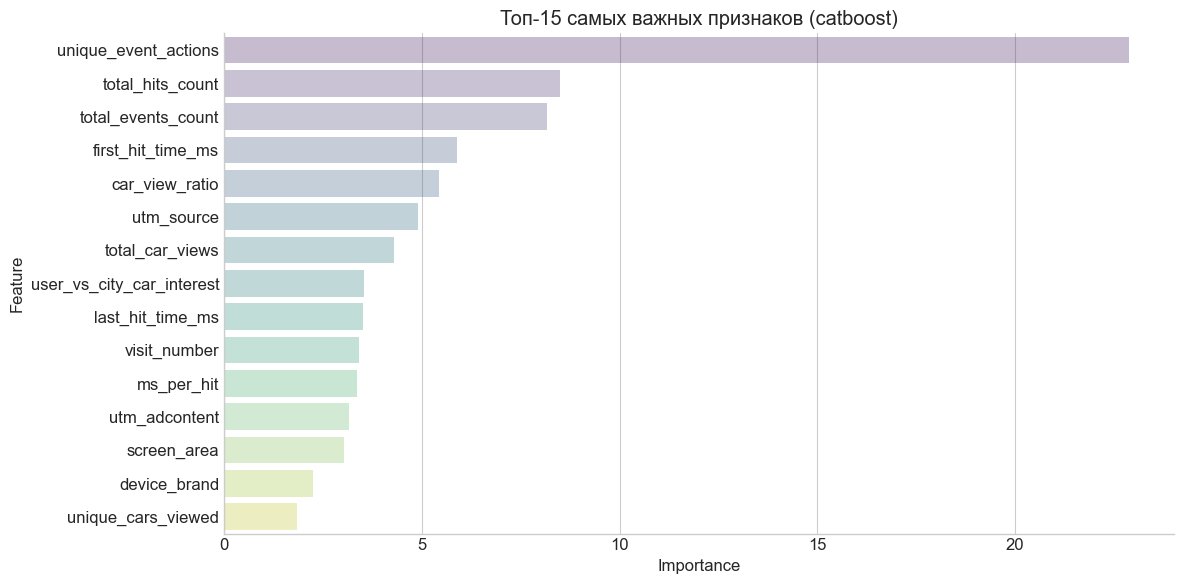

In [22]:
if hasattr(model.model, 'feature_importances_'):
    importances = model.model.feature_importances_
    
    # 1. Просто прогоняем тестовые признаки через предобработку
    X_test_clean = pipeline.preprocessor.transform(X_test)
    
    # 2. Имена колонок гарантированно лежат в самом чистом DataFrame!
    feature_names = X_test_clean.columns.tolist()

    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure()
    sns.barplot(
        data=fi_df.head(15),  # Показываем топ-15
        x='Importance',
        y='Feature',
        palette='viridis',
        alpha=PLOT_ALPHA
    )
    plt.title(f"Топ-15 самых важных признаков ({cfg.model.name})")
    plt.tight_layout()
    plt.show()
else:
    print("У выбранной модели нет встроенного атрибута feature_importances_.")

# Выводы по Feature Importance

- unique_event_actions - Огромный отрыв, логично что количество уникальных типов действий отражает глубину исследования сервиса. Пользватель который исопльзует много разных инструментов имеет другой паттерн поведения
- car_view_ratio и total_car_views -если пользователь сосредоточен на машинах а не ползает по всему сайту то конверсия возрастает
- visit_number прогрев клиента, чем больше раз заходил тем выше конверсия
- screen_area - возможно влияет адаптированность интерфейса под экран 

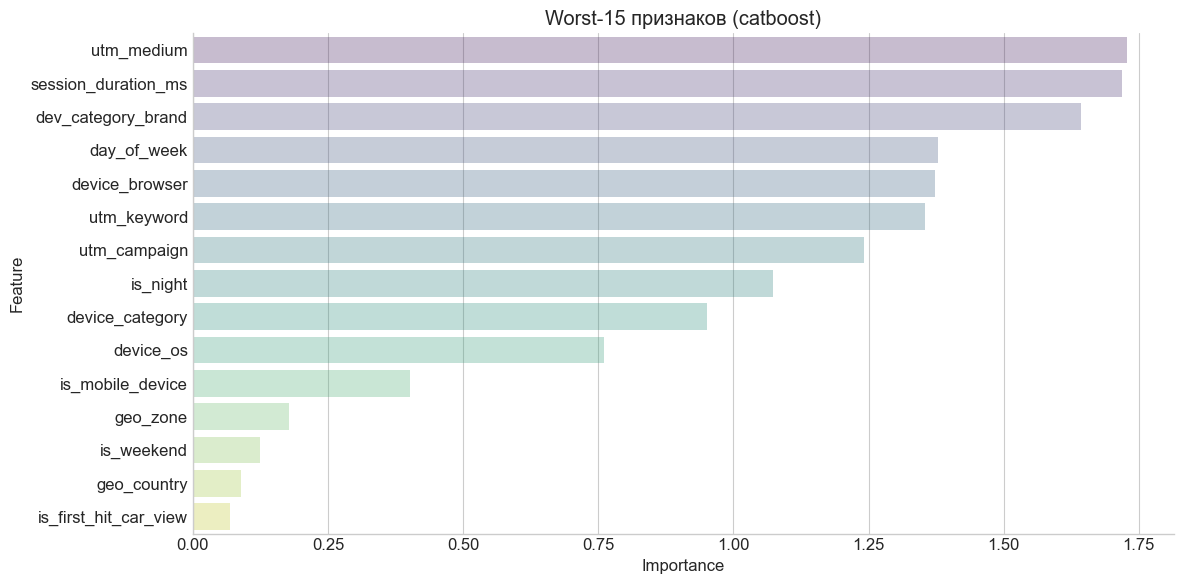

In [23]:
if hasattr(model.model, 'feature_importances_'):
    importances = model.model.feature_importances_
    
    # 1. Просто прогоняем тестовые признаки через предобработку
    X_test_clean = pipeline.preprocessor.transform(X_test)
    
    # 2. Имена колонок гарантированно лежат в самом чистом DataFrame!
    feature_names = X_test_clean.columns.tolist()

    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure()
    sns.barplot(
        data=fi_df.tail(15),  # Показываем худшие 15
        x='Importance',
        y='Feature',
        palette='viridis',
        alpha=PLOT_ALPHA
    )
    plt.title(f"Worst-15 признаков ({cfg.model.name})")
    plt.tight_layout()
    plt.show()
else:
    print("У выбранной модели нет встроенного атрибута feature_importances_.")

# Выводы по худшим фичам

- geo_country вероятно потому что большая часть всех запросов из России, поэтому этот параметр одинаково влияет как на таргет так и на пустые действия
- geo_zone как производная от geo_country
- is_weekend неожиданно но день недели не влияет на конверсию
- is_first_hit_car_view еще более неожиданно но то откуда пришел клиент по машине или на другую страницу также не сильно влияет на конверсию